In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

In [3]:
#加载和归一化CIFAR10
transform=transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))]
)
batch_size=4
trainset=torchvision.datasets.CIFAR10(root='./data',train=True,
                                       download=True,transform=transform)
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True,num_workers=2)
testset=torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)
testloader=torch.utils.data.DataLoader(testset,batch_size=batch_size,shuffle=False,num_workers=2)

classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

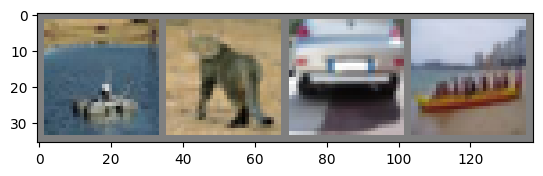

ship  cat   car   ship 


In [4]:
#吧加载到的图片画出来
import matplotlib.pyplot as plt
import numpy as np

#显示图像的函数
def imshow(img):
    #解标准化unnormalize
    img=img/2 + 0.5
    npimg=img.numpy()#变成numpy才能使用下面的np.transpose翻转函数
    plt.imshow(np.transpose(npimg,(1,2,0)))#在pytoch和在matplotlib图片的维度顺序不同
    plt.show()

dataiter=iter(trainloader) # 创建迭代器
images,labels=next(dataiter) # 获取一批次（Batch）数据

# show images
imshow(torchvision.utils.make_grid(images)) 
# 函数torchvison.utils.make_grid()是将你拿的一个批次(4张图片)的小图拼接成一个大图，中间留缝隙

#打印标签 print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

    

In [5]:
# 定义卷积神经网络
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,6,5) #卷积第一层
        self.pool=nn.MaxPool2d(2,2) #池化
        self.conv2=nn.Conv2d(6,16,5) #卷积第二层
        self.fc1=nn.Linear(16*5*5,120) #全连接层
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)
    #前向传播
    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))#卷积->激活->池化
        x=self.pool(F.relu(self.conv2(x)))#卷积->激活->池化
        x=torch.flatten(x,1)#展平做全连接层
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.fc3(x)
        return x

net=Net()

In [6]:
#定义损失函数和优化器，准备反向传播
import torch.optim as optim
criterion=nn.CrossEntropyLoss() #多元交叉熵损失函数
optimizer=optim.SGD(net.parameters(),lr=0.001,momentum=0.9)#随机下降梯度优化算法，保持0.9的动量

In [7]:
#训练网络，对数据集进行多次循环,这个步骤需要2分钟
for epoch in range(2):
    running_loss=0.0
    for i,data in enumerate(trainloader,0):
        inputs,labels =data
        optimizer.zero_grad()
        outputs=net(inputs)
        loss=criterion(outputs,labels)
        loss.backward()#反向传播
        optimizer.step()#更新

        #打印损失
        running_loss+=loss.item()
        if i%2000==1999:
            print(f'[{epoch+1},{i+1:5d}] loss:{running_loss/2000:.3f}')
            running_loss=0.0

print('Finished Training')

[1, 2000] loss:2.216
[1, 4000] loss:1.832
[1, 6000] loss:1.679
[1, 8000] loss:1.587
[1,10000] loss:1.518
[1,12000] loss:1.452
[2, 2000] loss:1.405
[2, 4000] loss:1.380
[2, 6000] loss:1.336
[2, 8000] loss:1.335
[2,10000] loss:1.325
[2,12000] loss:1.294
Finished Training


In [8]:
#快速保存好训练好的模型
PATH='./cifar_net.pth'
torch.save(net.state_dict(),PATH)

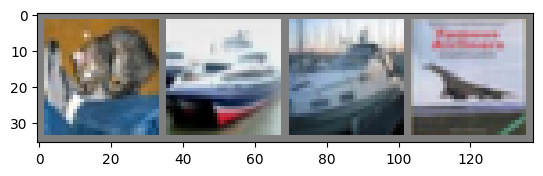

GroundTruth: cat   ship  ship  plane


In [9]:
#在测试数据上测试网络

#先挑选出一批次测试集图像，打印输出原图像和原标签
dataiter=iter(testloader)
images,labels=next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth:',' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [10]:
#加载回之前保存的模型
net=Net()
net.load_state_dict(torch.load(PATH,weights_only=True))

<All keys matched successfully>

In [11]:
#模型测试上面的测试集
outputs=net(images)
_,predicted=torch.max(outputs,1)
print('Predicted:',' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))


Predicted: cat   plane car   ship 


In [12]:
#网络在整个测试数据集上的表现：
correct=0 #正确预测的图片数
total=0 #总共参与测试的图片数
with torch.no_grad():#梯度拦截，不考虑整个计算图，只考虑数值
    for data in testloader:
        images,labels=data
        outputs=net(images)
        _,predicted=torch.max(outputs,1)
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 53 %


In [13]:
#测试集在每个类上的表现
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 70.4 %
Accuracy for class: car   is 72.0 %
Accuracy for class: bird  is 40.0 %
Accuracy for class: cat   is 33.3 %
Accuracy for class: deer  is 38.4 %
Accuracy for class: dog   is 38.8 %
Accuracy for class: frog  is 65.8 %
Accuracy for class: horse is 51.0 %
Accuracy for class: ship  is 60.8 %
Accuracy for class: truck is 69.4 %
